In [16]:
import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [2]:
import numpy as np
import pandas as pd

In [3]:
#  ====
# Inputs for creating strat model with gempy
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (350, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#  ====
# Inputs for fracture map
#  ====

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 5e-9 #[fractures/m3]

In [4]:
#geomodel_toolbox.create_strat_model(x_lims, y_lims, z_lims, resolution, strat_azimuth, strat_dip)

c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:266: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


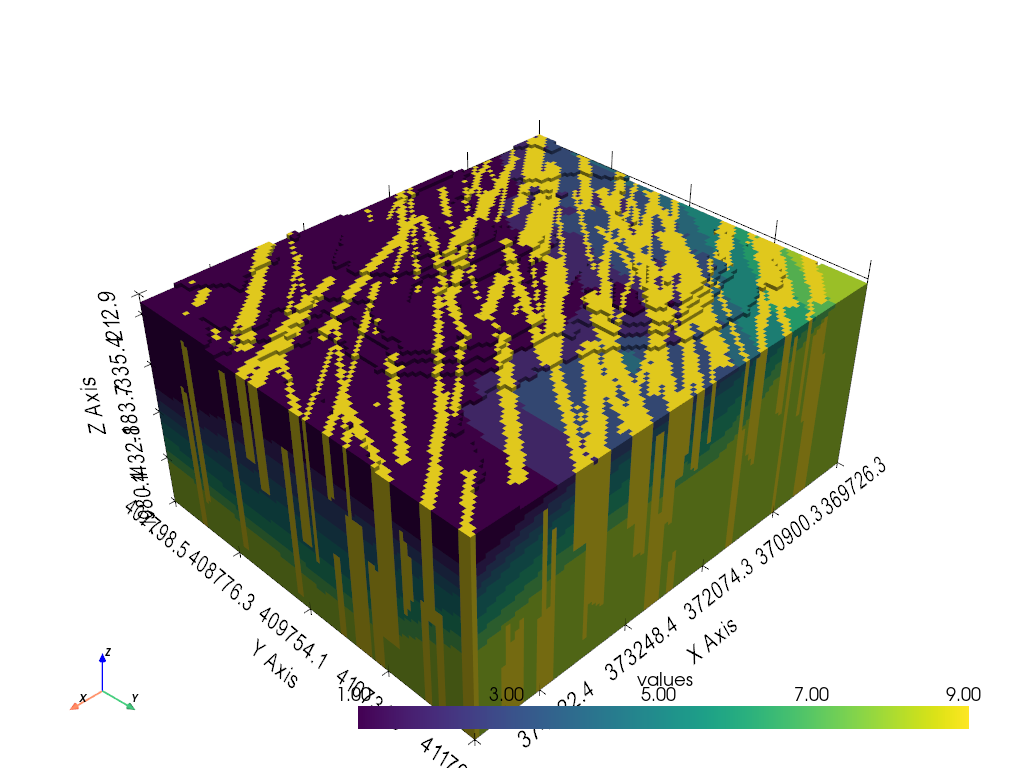

In [5]:
# Import previously defined topo+strat model
lith_topo, x_array, y_array, z_array= geomodel_toolbox.import_strat_model(show_plot=False)

# Generate fracture model based on inputs
mask, df = geomodel_toolbox.generate_fracture_model(x_array, y_array, z_array, aperture, radius, azimuth, density, show_plot=False)

# Combine to get topo+strat+frac model
geomodel = lith_topo.copy()
geomodel[(lith_topo > 0) & mask] = lith_topo.max()+1

# Plot results
geomodel_toolbox.plot_3d_model(geomodel, x_array, y_array, z_array)

In [19]:
# Define rock properties for easy access
ROCK_TYPES = {
    "M": {"poro": 0.2, "permx": 50},
    "B": {"poro": 0.02, "permx": 1e-2},
    "F": {"poro": 0.1, "permx": 1e3}
}

# Export to grid eclipse
grid = geomodel_toolbox.export_grdecl_from_geomodel(
    geomodel=geomodel,
    x_array=x_array,
    y_array=y_array,
    z_array=z_array,
    rock_types=ROCK_TYPES,
    out_file="grid.grdecl"
)

In [7]:
print(x_array[0]-x_array[1])
print(y_array[0]-y_array[1])
print(z_array[0]-z_array[1])

-46.961000000010245
-39.11300000001211
-39.16666666666674


In [ ]:
import pandas as pd
import rasterio

# Read wells
wells = pd.read_csv("gempy_inputs/borehole_data.csv")

# Sample DEM elevations
with rasterio.open("subset_dem.tif") as dem:
    coords = list(zip(wells["x"], wells["y"]))
    elevations = [v[0] for v in dem.sample(coords)]

wells["surface_z"] = elevations
wells["bottom_z"] = wells["surface_z"] - wells["depth"]

# Write ResInsight-style well path file
with open("vertical_wells.dev", "w") as f:

    for _, row in wells.iterrows():

        f.write(f"WELLNAME: {row['name']}\n")

        # Wellhead
        f.write(
            f"{row['x']:.2f} "
            f"{row['y']:.2f} "
            f"{row['surface_z']:.2f} "
            f"0.00\n"
        )

        # Bottom hole
        f.write(
            f"{row['x']:.2f} "
            f"{row['y']:.2f} "
            f"{row['bottom_z']:.2f} "
            f"{row['depth']:.2f}\n\n"
        )

print("Created vertical_wells.dev")

Created vertical_wells.dev


In [20]:
import pandas as pd
import numpy as np
import rasterio

# Optional but recommended for grid handling
import xtgeo


# ----------------------------
# 1. Load inputs
# ----------------------------
wells = pd.read_csv("gempy_inputs/borehole_data.csv")

# DEM raster
dem_path = "subset_dem.tif"
dem_src = rasterio.open(dem_path)


# ----------------------------
# 2. Helper: sample DEM
# ----------------------------
def get_dem_elevation(x, y):
    """Return DEM elevation at (x,y)."""
    row, col = dem_src.index(x, y)
    return dem_src.read(1)[row, col]


# ----------------------------
# 3. Build grid (example regular grid)
# ----------------------------

dx = x_array[1] - x_array[0]
dy = y_array[1] - y_array[0]
dz = z_array[1] - z_array[0]


def xyz_to_ijk(x, y, z):
    """Convert coordinates to IJK indices (1-based Eclipse)."""

    i = int(np.argmin(np.abs(x_array - x))) + 1
    j = int(np.argmin(np.abs(y_array - y))) + 1
    k = int(np.argmin(np.abs(z_array - z))) + 1

    return i, j, k


# ----------------------------
# 4. Convert well intervals
# ----------------------------
completions = []

for _, w in wells.iterrows():

    name = w["name"]
    x = w["x"]
    y = w["y"]

    #z_top = w["casing"]
    #z_bottom = w["depth"]

    # DEM correction (surface elevation)
    #z_surface = get_dem_elevation(x, y)

    # Convert to absolute elevation (assuming depth is positive downward)
    #z_top_abs = z_surface - z_top
    #z_bot_abs = z_surface - z_bottom

    # Ensure ordering
    #z_high = max(z_top_abs, z_bot_abs)
    #z_low = min(z_top_abs, z_bot_abs)

    # Convert to K indices
    #k1 = int(np.argmin(np.abs(z_array - z_high))) + 1
    #k2 = int(np.argmin(np.abs(z_array - z_low))) + 1

    z_top = w["casing"]
    z_bottom = w["depth"]

    z_surface = get_dem_elevation(x, y)

    z_top_abs = z_surface - z_top
    z_bot_abs = z_surface - z_bottom

    z_high = max(z_top_abs, z_bot_abs)
    z_low = min(z_top_abs, z_bot_abs)

    # convert to layer index robustly
    k_high = (z_array.max() - z_high) / abs(dz)
    k_low  = (z_array.max() - z_low) / abs(dz)

    k1 = int(np.floor(min(k_high, k_low))) + 1
    k2 = int(np.ceil(max(k_high, k_low))) + 1

    if k1 > k2:
        k1, k2 = k2, k1

    # Convert I,J from well location
    i, j, _ = xyz_to_ijk(x, y, z_array[0])

    completions.append((name, i, j, k1, k2))


# ----------------------------
# 5. Write Eclipse COMPDAT file
# ----------------------------
with open("sch.inc", "w") as f:
    f.write("--perforations in Eclipse format I, J, K1-K2, 1-based indices\n")
    f.write("COMPDAT\n")

    for name, i, j, k1, k2 in completions:
        f.write(f"PRD {i} {j} {k1} {k2} /\n")

    #f.write("/\n")

print("sch.inc written.")

sch.inc written.
